# Question 6 – Digital Media Attention and Food Price Inflation in Germany

## Research Question
How did digital media attention toward food price inflation in Germany change during periods of increasing food prices between 2023 and 2024?

## Data Sources
- Eurostat Food Price Index (CPI / HICP)
- YouTube Video Data (food inflation related videos in Germany)




In [5]:
from pathlib import Path

In [6]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from pathlib import Path


## 1. Load Eurostat JSON data
This converts the Eurostat JSON structure into a clean monthly DataFrame.


In [10]:
def eurostat_json_to_df(file_path, value_name):

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    time_index = data["dimension"]["time"]["category"]["index"]
    time_labels = data["dimension"]["time"]["category"]["label"]
    values = data["value"]

    rows = []

    for label_key, position in time_index.items():
        pos = str(position)

        if pos in values:
            rows.append({
                "datum_raw": time_labels[label_key],
                value_name: values[pos]
            })

    df = pd.DataFrame(rows)

    df["datum"] = pd.to_datetime(
        df["datum_raw"].str.replace("M", "-", regex=False),
        format="%Y-%m"
    )

    df.drop(columns=["datum_raw"], inplace=True)

    return df


## 2. Load YouTube video JSON
We extract video publication dates and engagement metrics.


In [13]:
def load_youtube_videos_json(file_path):

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    df = pd.DataFrame(data)
    
    print(df.columns)

    df.columns = [str(c).lower() for c in df.columns]

    date_col = None
    for c in ["publishedat", "published_at", "date"]:
        if c in df.columns:
            date_col = c

    view_col = None
    for c in ["viewcount", "views", "view_count"]:
        if c in df.columns:
            view_col = c

    like_col = None
    for c in ["likecount", "likes", "like_count"]:
        if c in df.columns:
            like_col = c

    df["datum"] = pd.to_datetime(df[date_col], errors="coerce")
    df["datum"] = df["datum"].dt.to_period("M").dt.to_timestamp()

    df["views"] = 0
    df["likes"] = 0

    monthly = (
        df.groupby("datum")
        .agg(
            video_count=("datum","count"),
            total_views=("views","sum"),
            total_likes=("likes","sum")
        )
        .reset_index()
    )

    return monthly


## 3. Load the datasets


In [14]:
eurostat_file = Path("eurostat_cpi_dairy.json")
youtube_file = Path("youtube_food_inflation_germany_videos.json")

price_df = eurostat_json_to_df(eurostat_file, "food_index")
youtube_df = load_youtube_videos_json(youtube_file)

print(price_df.head())
print(youtube_df.head())


Index(['video_id', 'title', 'description', 'channel', 'published_at'], dtype='str')
   food_index      datum
0        79.9 1996-01-01
1        79.9 1996-02-01
2        80.0 1996-03-01
3        80.1 1996-04-01
4        79.9 1996-05-01
       datum  video_count  total_views  total_likes
0 2022-06-01            1            0            0
1 2023-03-01            1            0            0
2 2023-05-01            2            0            0
3 2023-07-01            1            0            0
4 2024-03-01            1            0            0


/var/folders/7b/5swzj7bj65z2vyf6nw1s1zgr0000gn/T/ipykernel_35573/1068033942.py:28: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["datum"] = df["datum"].dt.to_period("M").dt.to_timestamp()


## 4. Merge datasets


In [15]:
analysis_df = pd.merge(price_df, youtube_df, on="datum", how="inner")

analysis_df["food_yoy_pct"] = analysis_df["food_index"].pct_change(12) * 100
analysis_df["food_mom_pct"] = analysis_df["food_index"].pct_change() * 100

analysis_df.head()


,food_index,datum,video_count,total_views,total_likes,food_yoy_pct,food_mom_pct
0,133.3,2022-06-01,1,0,0,NaN,NaN
1,164.2,2023-03-01,1,0,0,NaN,23.180795
2,163.0,2023-05-01,2,0,0,NaN,-0.730816
3,158.3,2023-07-01,1,0,0,NaN,-2.883436
4,156.7,2024-03-01,1,0,0,NaN,-1.010739


## 5. Visualisation


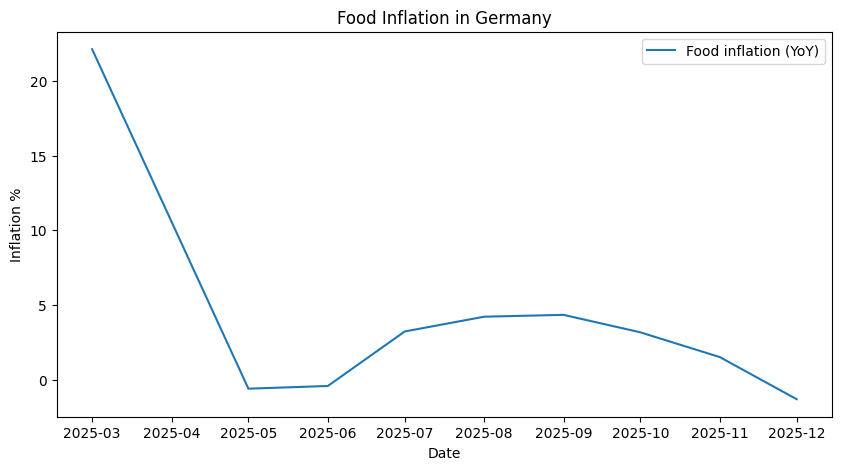

In [16]:
plt.figure(figsize=(10,5))
plt.plot(analysis_df["datum"], analysis_df["food_yoy_pct"], label="Food inflation (YoY)")
plt.title("Food Inflation in Germany")
plt.xlabel("Date")
plt.ylabel("Inflation %")
plt.legend()
plt.show()


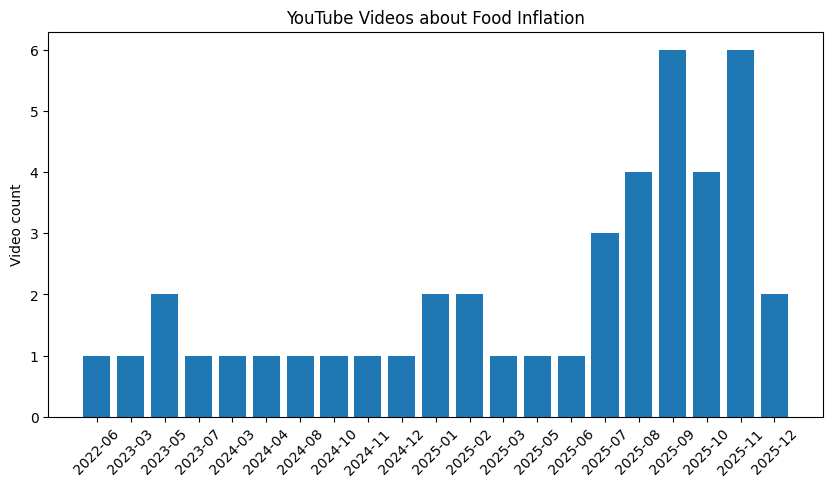

In [17]:
plt.figure(figsize=(10,5))
plt.bar(analysis_df["datum"].dt.strftime("%Y-%m"), analysis_df["video_count"])
plt.title("YouTube Videos about Food Inflation")
plt.xticks(rotation=45)
plt.ylabel("Video count")
plt.show()


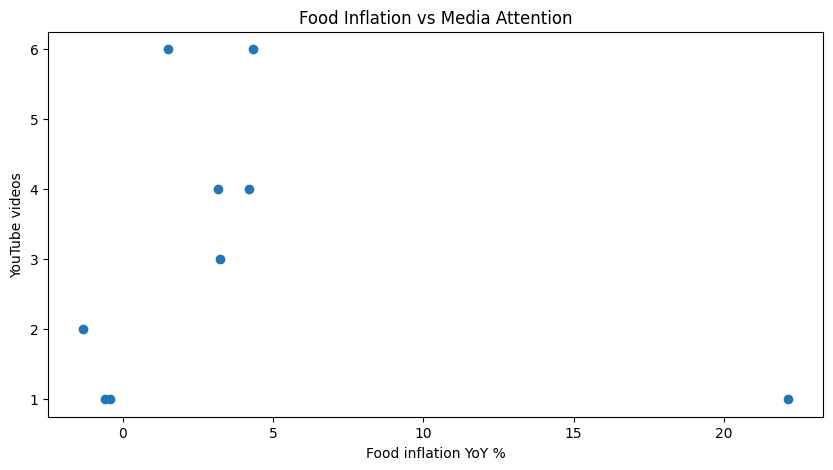

In [18]:
plt.figure(figsize=(10,5))
plt.scatter(analysis_df["food_yoy_pct"], analysis_df["video_count"])
plt.xlabel("Food inflation YoY %")
plt.ylabel("YouTube videos")
plt.title("Food Inflation vs Media Attention")
plt.show()


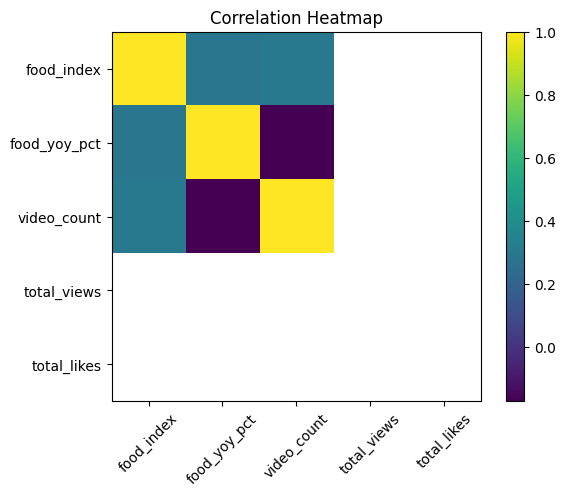

In [19]:
corr = analysis_df[["food_index","food_yoy_pct","video_count","total_views","total_likes"]].corr()

plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.colorbar()
plt.show()
